In [24]:
import os
from dotenv import load_dotenv

load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY was not found.")

In [25]:
from pydantic import BaseModel, Field
from typing import Literal

In [26]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite',
                             temperature=1.,
                             thinking_level="high",
                             google_api_key=GOOGLE_API_KEY)

In [27]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langchain_core.messages import SystemMessage

In [28]:
class FirmInput(BaseModel):
    """Common input for firm-level financial research tools."""
    firm_name: str = Field(description="Full name of the firm")
    stock_id: str = Field(description="6-digit Stock ID")

@tool(args_schema=FirmInput)
def search_stock_price(firm_name: str, stock_id: str) -> str:
    """Search for stock price."""
    return f"Current stock price of {firm_name}: 27.10 CNY"

@tool(args_schema=FirmInput)
def search_FCF_yield(firm_name: str, stock_id: str) -> str:
    """Search for forward free-cash-flow yield of the stock."""
    return f"FCF yield of {firm_name}: 7.1%"

@tool(args_schema=FirmInput)
def search_potential_risk(firm_name: str, stock_id: str) -> str:
    """Search for potential risk of the firm."""
    return f"Potential risk of {firm_name}: Affected by the slowdown in economic growth in recent years and the short-term imbalance between the supply of and demand for raw milk, demand for dairy products was somewhat subdued during the reporting period. Nevertheless, dairy products are essential consumer goods and therefore exhibit a certain degree of demand resilience. As consumer confidence gradually recovers, the dairy industry is showing increasingly divergent development trends. As the raw milk market returns to a balance between supply and demand, the dairy industry is expected to achieve healthier and more sustainable growth."

@tool(args_schema=FirmInput)
def search_revenue_growth(firm_name: str, stock_id: str) -> str:
    """Search for the firm's recent revenue growth trend."""
    return f"Revenue growth of {firm_name}: 2.3% year over year."

@tool(args_schema=FirmInput)
def search_profitability(firm_name: str, stock_id: str) -> str:
    """Search for profitability metrics such as gross and net profit margins."""
    return f"Profitability of {firm_name}: gross margin 33.5%, net margin 9.2%."

@tool(args_schema=FirmInput)
def search_balance_sheet_health(firm_name: str, stock_id: str) -> str:
    """Search for leverage and liquidity indicators from the firm's balance sheet."""
    return f"Balance-sheet health of {firm_name}: debt-to-equity 0.55, current ratio 1.25."

@tool(args_schema=FirmInput)
def search_valuation(firm_name: str, stock_id: str) -> str:
    """Search for common equity valuation multiples."""
    return f"Valuation of {firm_name}: P/E 16.8x, P/B 3.1x."

@tool(args_schema=FirmInput)
def search_dividend_history(firm_name: str, stock_id: str) -> str:
    """Search for the firm's dividend yield and recent dividend trend."""
    return f"Dividend history of {firm_name}: dividend yield 4.0%, dividends were stable over the last three years."

@tool(args_schema=FirmInput)
def search_earnings_growth(firm_name: str, stock_id: str) -> str:
    """Search for recent earnings-per-share growth and its trend."""
    return f"Earnings growth of {firm_name}: EPS grew 5.4% year over year (placeholder data)."

@tool(args_schema=FirmInput)
def search_return_on_equity(firm_name: str, stock_id: str) -> str:
    """Search for return on equity and its recent direction."""
    return f"Return on equity of {firm_name}: 18.6%, up from 17.9% in the prior year (placeholder data)."

@tool(args_schema=FirmInput)
def search_cash_flow_trend(firm_name: str, stock_id: str) -> str:
    """Search for operating and free-cash-flow trends."""
    return f"Cash-flow trend of {firm_name}: operating cash flow rose 6.1% and free cash flow rose 4.8% year over year (placeholder data)."

@tool(args_schema=FirmInput)
def search_earnings_quality(firm_name: str, stock_id: str) -> str:
    """Search for indicators of earnings quality and cash conversion."""
    return f"Earnings quality of {firm_name}: operating cash flow was 1.08 times net income (placeholder data)."

@tool(args_schema=FirmInput)
def search_capital_expenditure(firm_name: str, stock_id: str) -> str:
    """Search for capital-expenditure levels and investment intensity."""
    return f"Capital expenditure of {firm_name}: capex was 5.7% of revenue, versus 6.2% in the prior year (placeholder data)."

@tool(args_schema=FirmInput)
def search_working_capital(firm_name: str, stock_id: str) -> str:
    """Search for working-capital efficiency and the cash-conversion cycle."""
    return f"Working-capital efficiency of {firm_name}: cash-conversion cycle was 24 days, improving by 3 days year over year (placeholder data)."

@tool(args_schema=FirmInput)
def search_debt_service_capacity(firm_name: str, stock_id: str) -> str:
    """Search for interest coverage and the firm's capacity to service debt."""
    return f"Debt-service capacity of {firm_name}: interest-coverage ratio was 9.4 times (placeholder data)."

@tool(args_schema=FirmInput)
def search_peer_comparison(firm_name: str, stock_id: str) -> str:
    """Compare the firm's growth, profitability, and valuation with peers."""
    return f"Peer comparison for {firm_name}: net margin was 1.2 percentage points above the peer median, while P/E was 0.9 times the peer median (placeholder data)."

@tool(args_schema=FirmInput)
def search_analyst_expectations(firm_name: str, stock_id: str) -> str:
    """Search for consensus analyst revenue and earnings expectations."""
    return f"Analyst expectations for {firm_name}: consensus forecasts 4.6% revenue growth and 6.8% EPS growth next year (placeholder data)."

@tool(args_schema=FirmInput)
def search_shareholder_returns(firm_name: str, stock_id: str) -> str:
    """Search for buybacks, dividends, and total shareholder distributions."""
    return f"Shareholder returns from {firm_name}: dividends and buybacks equaled 62% of free cash flow in the latest year (placeholder data)."

finance_tools = [
    search_stock_price,
    search_FCF_yield,
    search_potential_risk,
    search_revenue_growth,
    search_profitability,
    search_balance_sheet_health,
    search_valuation,
    search_dividend_history,
    search_earnings_growth,
    search_return_on_equity,
    search_cash_flow_trend,
    search_earnings_quality,
    search_capital_expenditure,
    search_working_capital,
    search_debt_service_capacity,
    search_peer_comparison,
    search_analyst_expectations,
    search_shareholder_returns,
]

In [29]:
PROPOSE_MODEL  = "gemini-3.1-flash-lite-preview"   # cheap, fast → idea_maker
CRITIQUE_MODEL = "gemini-3.1-pro-preview"            # careful, sharp → idea_hater
FORMAT_MODEL   = "gemini-3.1-flash-lite-preview"   # cheap, deterministic → formatter

proposer = ChatGoogleGenerativeAI(
    model=PROPOSE_MODEL,
    temperature=1.0,
    thinking_level="low",
    google_api_key=GOOGLE_API_KEY,
)

critic = ChatGoogleGenerativeAI(
    model=CRITIQUE_MODEL,
    temperature=0.4,
    thinking_level="high",
    google_api_key=GOOGLE_API_KEY,
)

formatter_llm = ChatGoogleGenerativeAI(
    model=FORMAT_MODEL,
    temperature=0.0,
    google_api_key=GOOGLE_API_KEY,
)

In [30]:
from dataclasses import dataclass

@dataclass
class IdeaContext:
    firm_name: str
    stock_id: str
    num_rounds: int = 4
    constraints: str = "Use the provided tools only."

In [31]:
class Idea(BaseModel):
    """A concrete investigation plan for a stock"""
    title: str = Field(description="One-line title.")
    summary: str = Field(description="2-3 sentences describing the plan.")
    method: str = Field(description="How you would implement it.")
    expected_outcome: str = Field(description="What you would produce.")

class Critique(BaseModel):
    """Structured critique of a stock investigation plan."""
    feasibility: str = Field(description="Concrete feasibility issues, if any.")
    helpfulsness: str = Field(description="Whether the plan would be enough for stock investment decision.")
    constraints_respected: bool = Field(description="True if the plan respects the constraints.")
    fixes: list[str] = Field(description="Concrete fixes to make on the next revision.")

In [32]:
def _type_name(ann) -> str:
    # str(int) -> "<class 'int'>", str(list[str]) -> "list[str]" — clean both.
    s = str(ann).replace("typing.", "")
    if s.startswith("<class '") and s.endswith("'>"):
        return s[len("<class '"):-len("'>")]
    return s

def schema_field_brief(schema) -> str:
    """Render a Pydantic schema as a bullet list of fields + descriptions.

    Used inside *generator* prompts so the writer knows what to cover, while
    still producing free-form prose (no JSON)."""
    lines = []
    for name, field in schema.model_fields.items():
        t = _type_name(field.annotation)
        desc = field.description or ""
        lines.append(f"- {name} ({t}): {desc}")
    return "\n".join(lines)

def make_formatter(schema, input_field: str, output_field: str, tag: str):
    """Build a node that converts state[input_field] (str) into a `schema` instance
    and writes it to state[output_field]. Tags the LLM call so the logger
    can attribute it."""
    structured = formatter_llm.with_structured_output(schema)
    sys = SystemMessage(
        f"You are a formatter. Convert the user's text into a {schema.__name__} "
        f"object. Preserve all substantive content. Do not invent new facts. "
        f"If a field is not explicitly stated, infer it conservatively from context."
    )

    def formatter(state, runtime):
        raw = state[input_field]
        obj = structured.invoke([sys, HumanMessage(raw)], config={"tags": [tag]})
        return {output_field: obj}
    return formatter

In [33]:
from typing import TypedDict, Optional

class IdeaState(TypedDict, total=False):
    raw_idea: str
    current_idea: Idea
    raw_critique: str
    current_critique: Optional[Critique]
    round: int

In [34]:
from langgraph.runtime import Runtime

def finance_tool_brief(tools) -> str:
    """Describe the available finance tools for planning and critique prompts."""
    lines = []
    for tool in tools:
        fields = tool.args_schema.model_fields
        arguments = ", ".join(
            f"{name}: {_type_name(field.annotation)}"
            for name, field in fields.items()
        )
        lines.append(f"- {tool.name}({arguments}): {tool.description}")
    return "\n".join(lines)

AVAILABLE_FINANCE_TOOLS = finance_tool_brief(finance_tools)

MAKER_SYSTEM = (
    "You are idea_maker. You generate one concrete stock research plan.\n"
    "Design the plan around the available finance tools listed below. Do not claim that \n"
    "a tool or data source exists unless it appears in this list.\n\n"
    "Available finance tools:\n"
    f"{AVAILABLE_FINANCE_TOOLS}\n\n"
    "Write naturally in prose. A downstream specialist will extract these fields "
    "from your response, so make sure every field has enough material:\n\n"
    f"{schema_field_brief(Idea)}"
)

def idea_maker(state: IdeaState, runtime: Runtime[IdeaContext]) -> IdeaState:
    ctx = runtime.context
    round_n = state.get("round", 0) + 1
    critique = state.get("current_critique")

    if critique is None:
        user = (
            f"Firm name:\n{ctx.firm_name}\n\n"
            f"Stock ID:\n{ctx.stock_id}\n\n"
            f"Constraints:\n{ctx.constraints}\n\n"
            f"Propose a concrete plan."
        )
    else:
        prev = state["current_idea"]
        user = (
            f"Firm name:\n{ctx.firm_name}\n\n"
            f"Stock ID:\n{ctx.stock_id}\n\n"
            f"Constraints:\n{ctx.constraints}\n\n"
            f"Your previous plan:\n{prev.model_dump_json(indent=2)}\n\n"
            f"idea_hater's critique:\n{critique.model_dump_json(indent=2)}\n\n"
            f"Revise. Address every fix the critic listed. Return one revised plan."
        )

    msg = proposer.invoke(
        [SystemMessage(MAKER_SYSTEM), HumanMessage(user)],
        config={"tags": ["idea_maker"]},
    )
    return {"raw_idea": msg.text, "round": round_n}

In [35]:
HATER_SYSTEM = (
    "You are idea_hater. You critique a stock research plan hard but fairly.\n"
    "Judge whether the plan can be completed with the available finance tools listed \n"
    "below. Identify requested evidence that no listed tool can provide, and propose \n"
    "fixes that use the listed tools where possible.\n\n"
    "Available finance tools:\n"
    f"{AVAILABLE_FINANCE_TOOLS}\n\n"
    "Write naturally in prose. A downstream specialist will extract these fields "
    "from your response, so make sure every field has enough material:\n\n"
    f"{schema_field_brief(Critique)}"
)

def idea_hater(state: IdeaState, runtime: Runtime[IdeaContext]) -> IdeaState:
    ctx = runtime.context
    idea = state["current_idea"]
    user = (
        f"Firm name:\n{ctx.firm_name}\n\n"
        f"Stock ID:\n{ctx.stock_id}\n\n"
        f"Plan under review:\n{idea.model_dump_json(indent=2)}\n\n"
        f"Critique it."
    )
    msg = critic.invoke(
        [SystemMessage(HATER_SYSTEM), HumanMessage(user)],
        config={"tags": ["idea_hater"]},
    )
    return {"raw_critique": msg.text}

In [36]:
format_idea = make_formatter(
    schema=Idea,
    input_field="raw_idea",
    output_field="current_idea",
    tag="format_idea",
)

format_critique = make_formatter(
    schema=Critique,
    input_field="raw_critique",
    output_field="current_critique",
    tag="format_critique",
)

In [37]:
from langgraph.graph import StateGraph, START, END

def route_after_format_critique(state: IdeaState, runtime: Runtime[IdeaContext]) -> str:
    if state["round"] < runtime.context.num_rounds:
        return "idea_maker"
    return END

In [38]:
graph = (
    StateGraph(IdeaState, context_schema=IdeaContext)
    .add_node("idea_maker", idea_maker)
    .add_node("format_idea", format_idea)
    .add_node("idea_hater", idea_hater)
    .add_node("format_critique", format_critique)
    .add_edge(START, "idea_maker")
    .add_edge("idea_maker", "format_idea")
    .add_edge("format_idea", "idea_hater")
    .add_edge("idea_hater", "format_critique")
    .add_conditional_edges(
        "format_critique",
        route_after_format_critique,
        {"idea_maker": "idea_maker", END: END},
    )
    .compile()
)

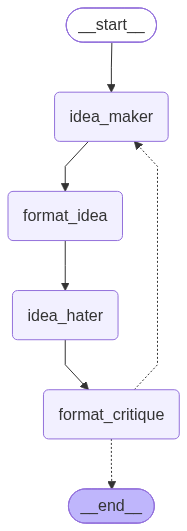

In [39]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
import json, time
from pathlib import Path
from langchain_core.callbacks import BaseCallbackHandler

class JsonlLLMLogger(BaseCallbackHandler):
    """Append one JSON line per LLM response. Also prints a short preview."""

    def __init__(self, path, verbose: bool = True):
        self.path = Path(path)
        self.path.write_text("")          # truncate per run
        self.verbose = verbose
        self._pending: dict[str, dict] = {}

    def _write(self, entry: dict) -> None:
        with self.path.open("a") as f:
            f.write(json.dumps(entry, default=str) + "\n")
            f.flush()
        if self.verbose:
            tags = ",".join(entry.get("tags") or []) or "?"
            preview = (entry.get("output", [""])[0] or "").replace("\n", " ")[:120]
            print(f"[{tags}] {preview}{'…' if len(preview) == 120 else ''}")

    # Fires when a chat model call begins. We stash inputs keyed by run_id
    # so we can pair them with the on_llm_end event below.
    def on_chat_model_start(self, serialized, messages, *, run_id,
                            tags=None, metadata=None, **kwargs) -> None:
        flat = []
        for batch in messages:
            for m in batch:
                flat.append({"type": type(m).__name__, "content": getattr(m, "content", "")})
        self._pending[str(run_id)] = {
            "tags": list(tags or []),
            "model": (serialized or {}).get("kwargs", {}).get("model"),
            "messages": flat,
        }

    def on_llm_end(self, response, *, run_id, **kwargs) -> None:
        rid = str(run_id)
        inp = self._pending.pop(rid, {})
        outputs = []
        for batch in response.generations:
            for gen in batch:
                outputs.append(getattr(gen, "text", "") or "")
        usage = (response.llm_output or {}).get("token_usage")
        self._write({
            "ts": time.time(),
            "run_id": rid,
            "tags": inp.get("tags", []),
            "model": inp.get("model"),
            "input": inp.get("messages", []),
            "output": outputs,
            "usage": usage,
        })

In [41]:
LOG_PATH = "fin_llm_log.json"
logger = JsonlLLMLogger(LOG_PATH)

ctx = IdeaContext(
    firm_name="Yili",
    stock_id = "600887",
    num_rounds=2,
    constraints="Use the provided tools only.",
)

result = graph.invoke({}, context=ctx, config={"callbacks": [logger]})

[seq:step:1,idea_maker] ### Title Comprehensive Quality and Value Assessment of Yili (600887)  ### Summary This research plan aims to evaluate Y…
[seq:step:1,format_idea] {   "title": "Comprehensive Quality and Value Assessment of Yili (600887)",   "summary": "This research plan aims to eva…
[seq:step:1,idea_hater] Listen, this plan is decent on the surface, but it throws around buzzwords like "competitive moat" and "operational effi…
[seq:step:1,format_critique] {   "feasibility": "The plan suffers from a mapping error where stated objectives like profitability and risk are not su…
[seq:step:1,idea_maker] ### Revised Plan  **Title** Fundamental Quality and Risk Assessment for Yili (600887)  **Summary** This research plan ev…
[seq:step:1,format_idea] {   "title": "Fundamental Quality and Risk Assessment for Yili (600887)",   "summary": "This research plan evaluates Yil…
[seq:step:1,idea_hater] This research plan is highly feasible but suffers from severe tunnel vision.   In terms of **